In [50]:
#1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [51]:
#2. Load dataset

df = pd.read_csv("IMDB Dataset.csv")
df.head(10)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [52]:
#3. Convert labels into numbers
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['sentiment'] = encoder.fit_transform(df['sentiment'])
df['sentiment']

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int32

In [53]:
#4. Seperate features & labels
X = df['review']
y = df['sentiment']

In [54]:
#5. Spliting into training & testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [55]:
#6. Tokenization

from tensorflow.keras.preprocessing.text import Tokenizer

#Tokenizer will keep only to 10,000 most frequent words
tokenizer = Tokenizer(num_words=10000)

#Learn words from training data
tokenizer.fit_on_texts(X_train)

# Convert text into numbers
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [56]:
#7. Padding - Neural networks need fixed-size input. Hence it makes all reviews of equal lengths
maxlen = 200
X_train = pad_sequences(X_train, maxlen=200)
X_test = pad_sequences(X_test, maxlen=200)

In [57]:
#8. Build Deep Neural Network

model = Sequential()

#Input Layer + Hidden Layer 1
model.add(Dense(128, activation='relu', input_shape=(maxlen,)))

#Hidden Layer 2
model.add(Dense(64, activation='relu'))

#Output Layer
model.add(Dense(1, activation='sigmoid'))

C:\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
#9. Compile the model

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [59]:
#10. Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4971 - loss: 31.3838 - val_accuracy: 0.4989 - val_loss: 0.9212
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4991 - loss: 0.7659 - val_accuracy: 0.4992 - val_loss: 0.7749
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5001 - loss: 0.7047 - val_accuracy: 0.4950 - val_loss: 0.7415
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5052 - loss: 0.6949 - val_accuracy: 0.5002 - val_loss: 0.7421
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5052 - loss: 0.6927 - val_accuracy: 0.5029 - val_loss: 0.7385
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5030 - loss: 0.6919 - val_accuracy: 0.5005 - val_loss: 0.7328
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5027 - loss: 0.6958 - val_accuracy: 0.5010 - val_loss: 0.7223
Epoch 8/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5024 - loss: 0.6924 -

In [47]:
#11. Evaluate the model

loss, accuracy = model.evaluate(X_test, y_test)
print("Loss: ", loss)
print("Accuracy: ", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5036 - loss: 0.7738
Loss:  0.773849368095398
Accuracy:  0.503600001335144


In [48]:
#12. Predictions

predictions = model.predict(X_test[:5])

for i in range(5):
    if predictions[i] > 0.5:
        print("Review ",i+1, ": Positive")
    else:
        print("Review ",i+1, ": Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Review  1 : Negative
Review  2 : Negative
Review  3 : Negative
Review  4 : Negative
Review  5 : Negative


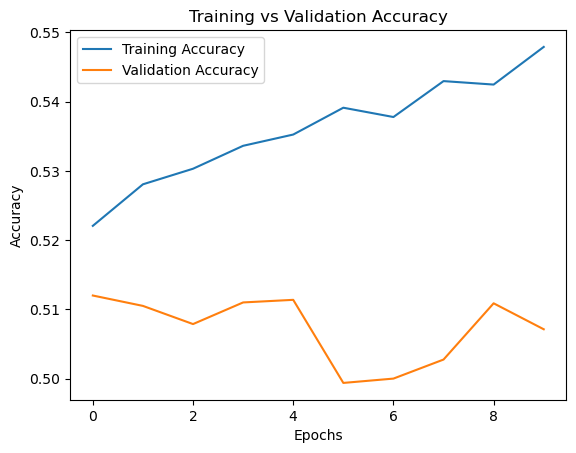

In [49]:
#13. Plot Accuracy Graph

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()
plt.show()